<a href="https://colab.research.google.com/github/Rakshiii365/pyhton-sql/blob/main/python_sql_ecommers_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host='127.0.0.1',
                             user='root',
                             password='raks',
                             database='ecommers',
                             auth_plugin='mysql_native_password')

cur = db.cursor()

Q1. list all unique cities where custmers are located


In [ ]:
query = """select distinct(customer_city) from customers"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df.head(5)

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


Q2. Count the number of orders placed in 2017.

In [ ]:
query = """select count(order_purchase_timestamp) from orders where year(order_purchase_timestamp) = 2017"""
cur.execute(query)
data = cur.fetchall()
print("total orders placed in 2017 =",data[0][0])


total orders placed in 2017 = 45101


Q3. Find the total sales per category.


In [ ]:
query = """select upper(products.product_category) category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['category','sales'])
df.head(5)

,category,sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33


Q4. Calculate the percentage of orders that were paid in installments.



In [ ]:
query = """ select sum(case when payment_installments >=1 then 1
else 0 end)/count(*)*100 from payments"""
cur.execute(query)
data = cur.fetchall()
print('the percentage of orers that were paid in installments are =',data[0][0],'%')

the percentage of orers that were paid in installments are = 99.9981 %


Q5. Count the number of customers from each state.

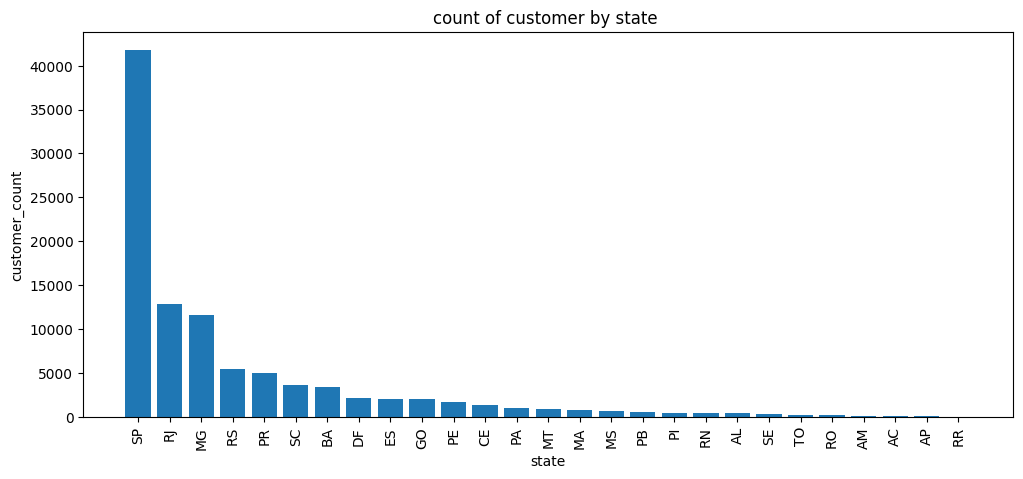

In [ ]:
query = """select customer_state,count(customer_id)
from customers group by customer_state"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=['state','customer_count'])
df = df.sort_values(by = "customer_count", ascending= False)

plt.figure(figsize=(12,5))
plt.bar(df['state'],df['customer_count'])
plt.xticks(rotation = 90)
plt.xlabel("state")
plt.ylabel("customer_count")
plt.title("count of customer by state ")
plt.show()

Q6. Calculate the number of orders per month in 2018.

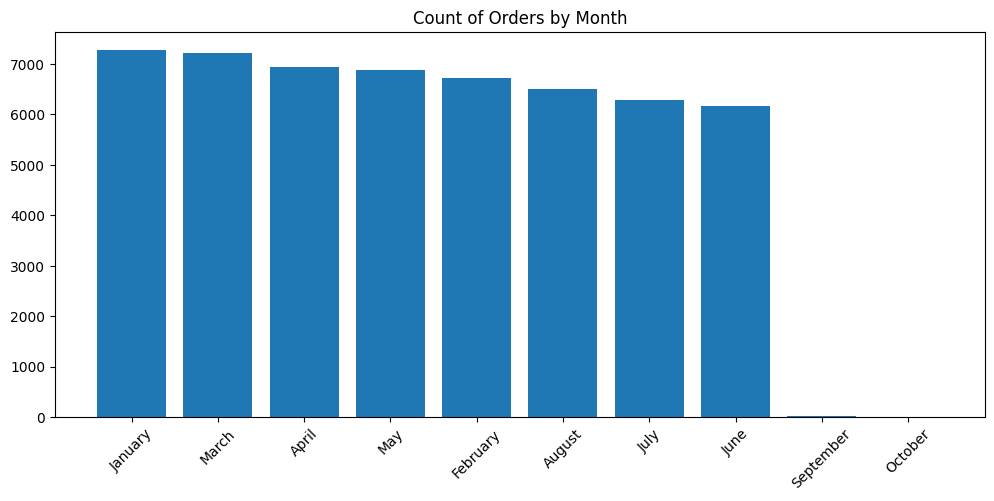

In [ ]:
query = """select monthname(order_purchase_timestamp) as months, count(order_id) from orders as order_count
where year(order_purchase_timestamp) = 2018
group by months"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns=['months','id_count'])
df = df.sort_values(by = 'id_count', ascending=False)
o = ['janaury','febraury','march','april','may','june','july','august','september','october']


plt.figure(figsize=(12,5))
plt.xticks(rotation = 45)
plt.bar(df['months'],df['id_count'])
plt.title("Count of Orders by Month")
plt.show()

Q7. find the average number of producrs per order,grouped by customer city

In [ ]:
query = """with count_per_order as
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) as avg_customers_count from customers
join count_per_order on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by avg_customers_count desc;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data,columns=['states','avg_sales'])
df.head(5)

,states,avg_sales
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
